In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [ ]:
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [ ]:
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [ ]:
print(df.columns[df.isnull().any()])

Index(['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')


In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [2]:
# Convert pickup to datetime
df["pickup"] = pd.to_datetime(df["pickup"])

# Sort by pickup time
df = df.sort_values("pickup")

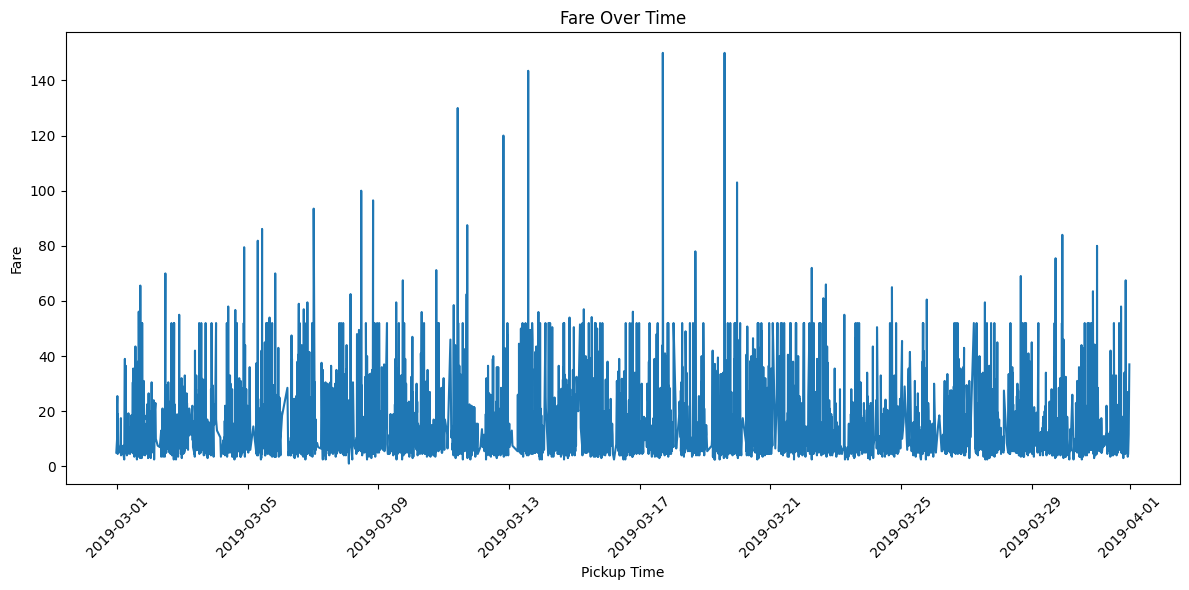

In [3]:
# Line chart
plt.figure(figsize=(12, 6))
plt.plot(df["pickup"], df["fare"])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
# Calculate total fare for each pickup borough
borough_fare = df.groupby("pickup_borough")["fare"].sum()


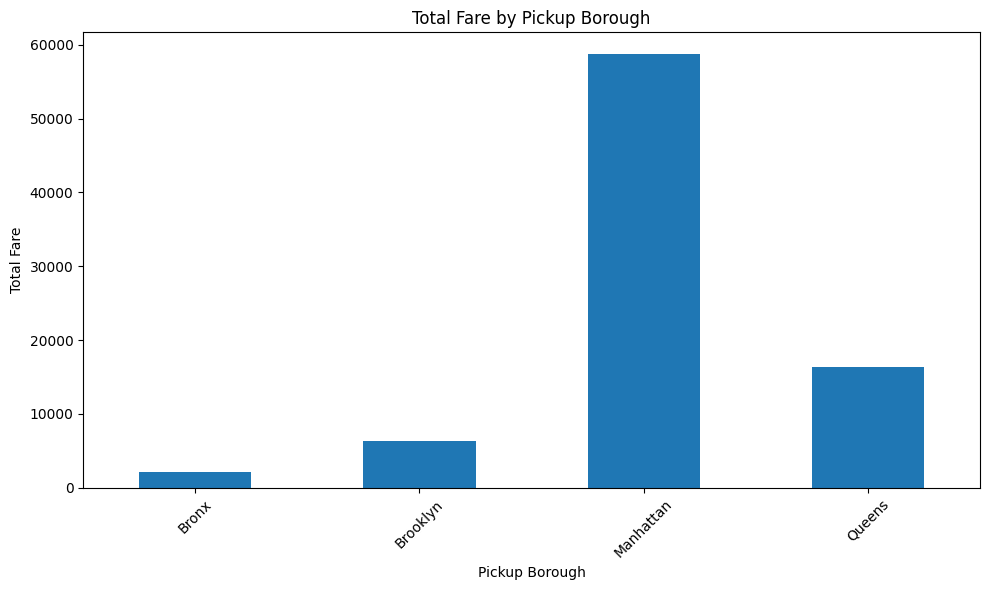

In [5]:
# Bar chart
plt.figure(figsize=(10, 6))
borough_fare.plot(kind="bar")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# Count trips for each payment method
payment_counts = df["payment"].value_counts()


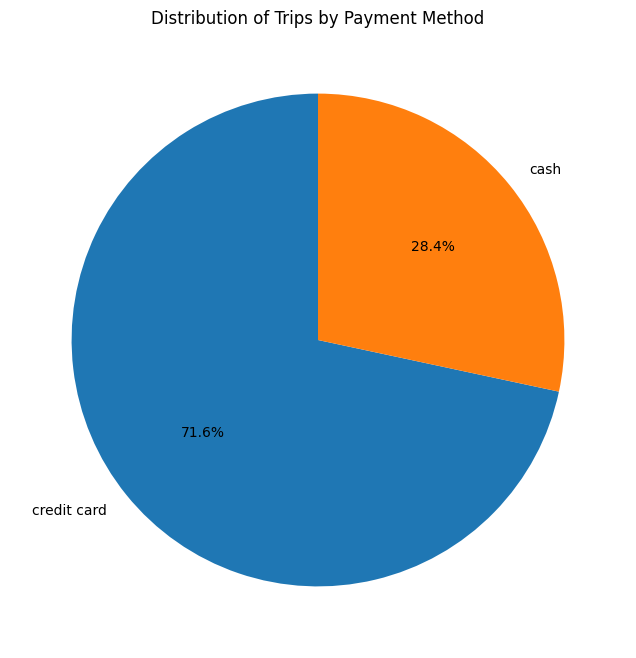

In [7]:
# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")
plt.show()


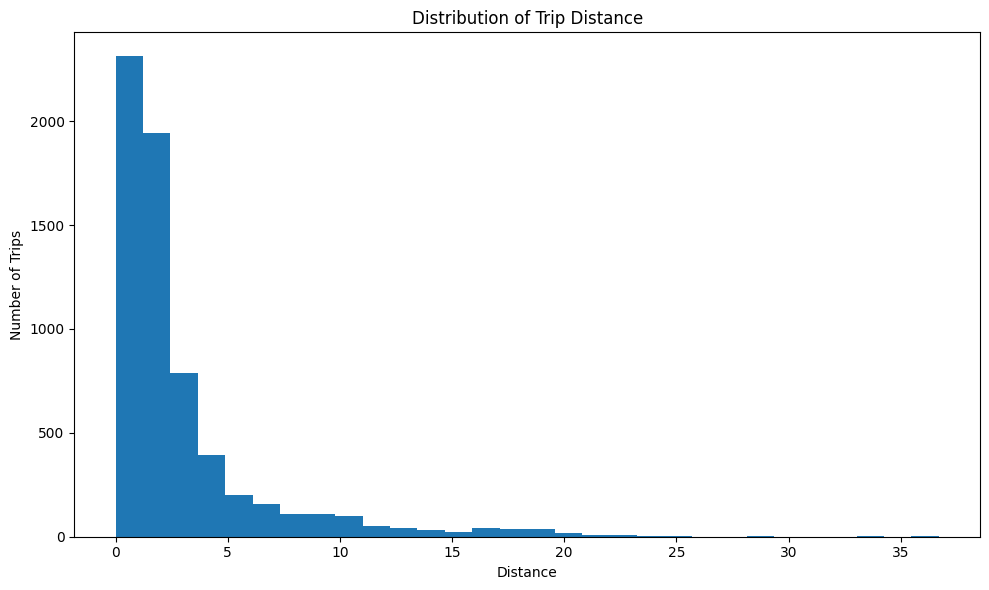

In [8]:
#Histogram
plt.figure(figsize=(10, 6))

plt.hist(df["distance"].dropna(), bins=30)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.tight_layout()
plt.show()


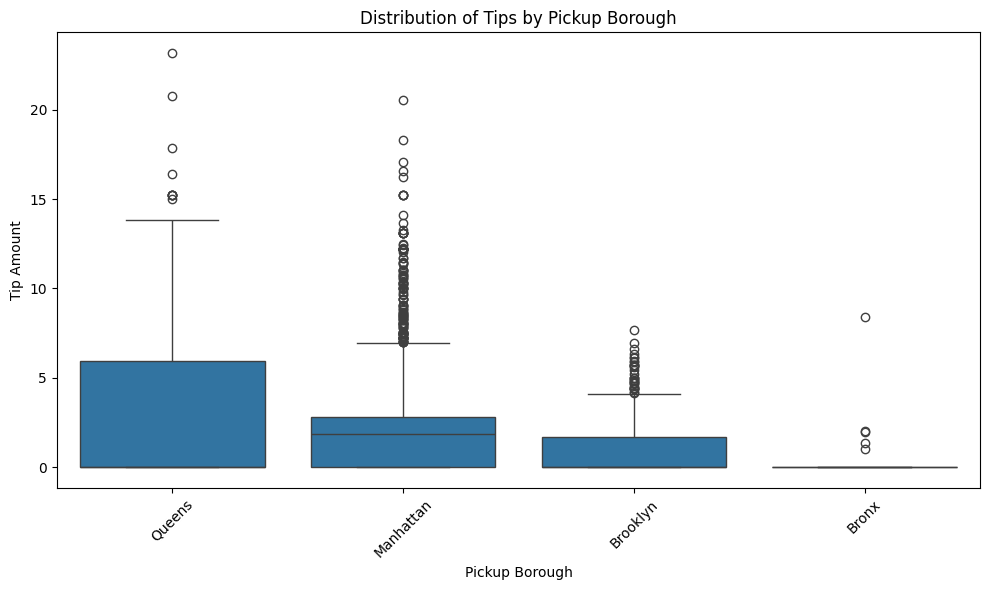

In [9]:
#boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(x="pickup_borough", y="tip", data=df)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.title("Distribution of Tips by Pickup Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


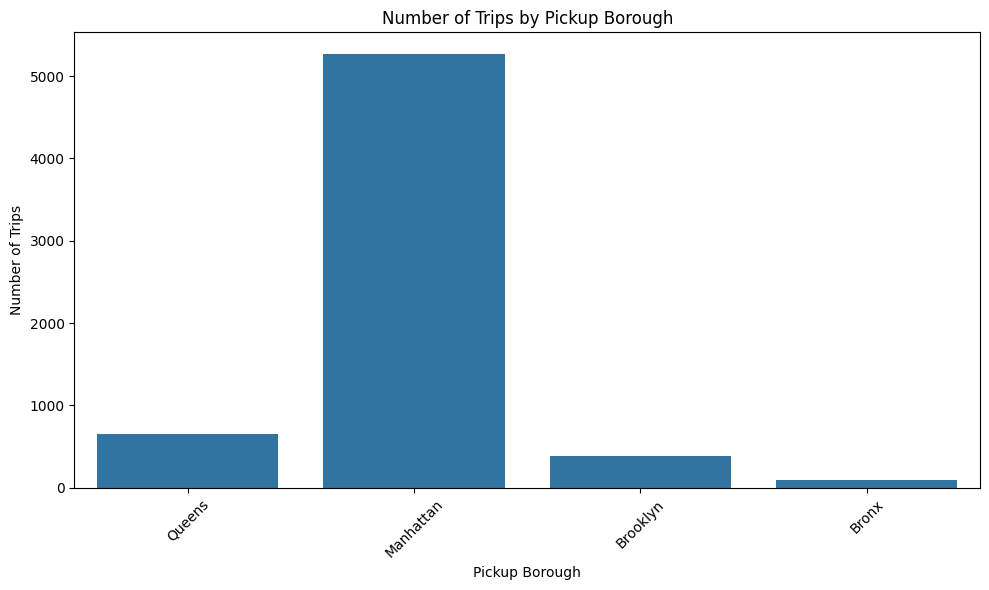

In [10]:
#count plot

plt.figure(figsize=(10, 6))

sns.countplot(x="pickup_borough", data=df)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

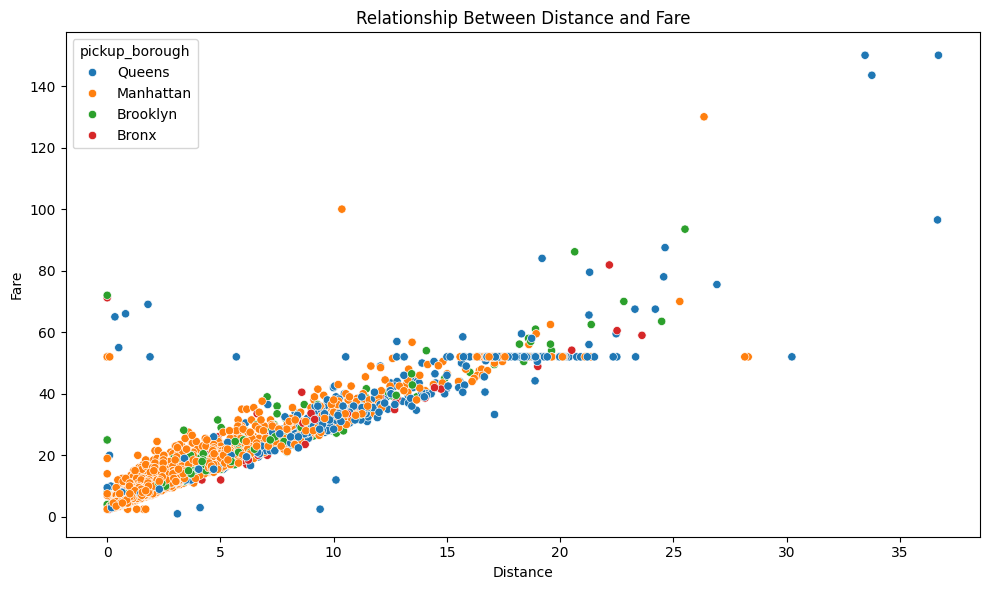

In [11]:
#Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="distance",
    y="fare",
    hue="pickup_borough",
    data=df
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Relationship Between Distance and Fare")
plt.tight_layout()
plt.show()


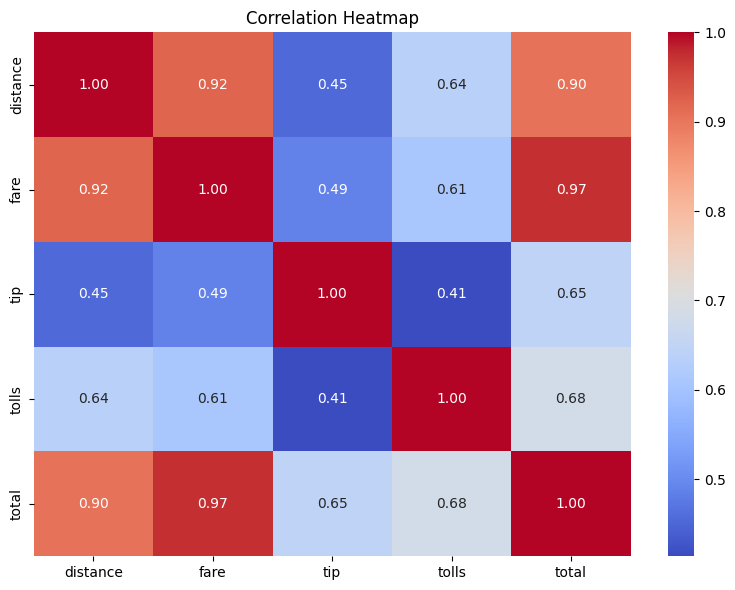

In [12]:
#Heatmap
# Select numerical columns
corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

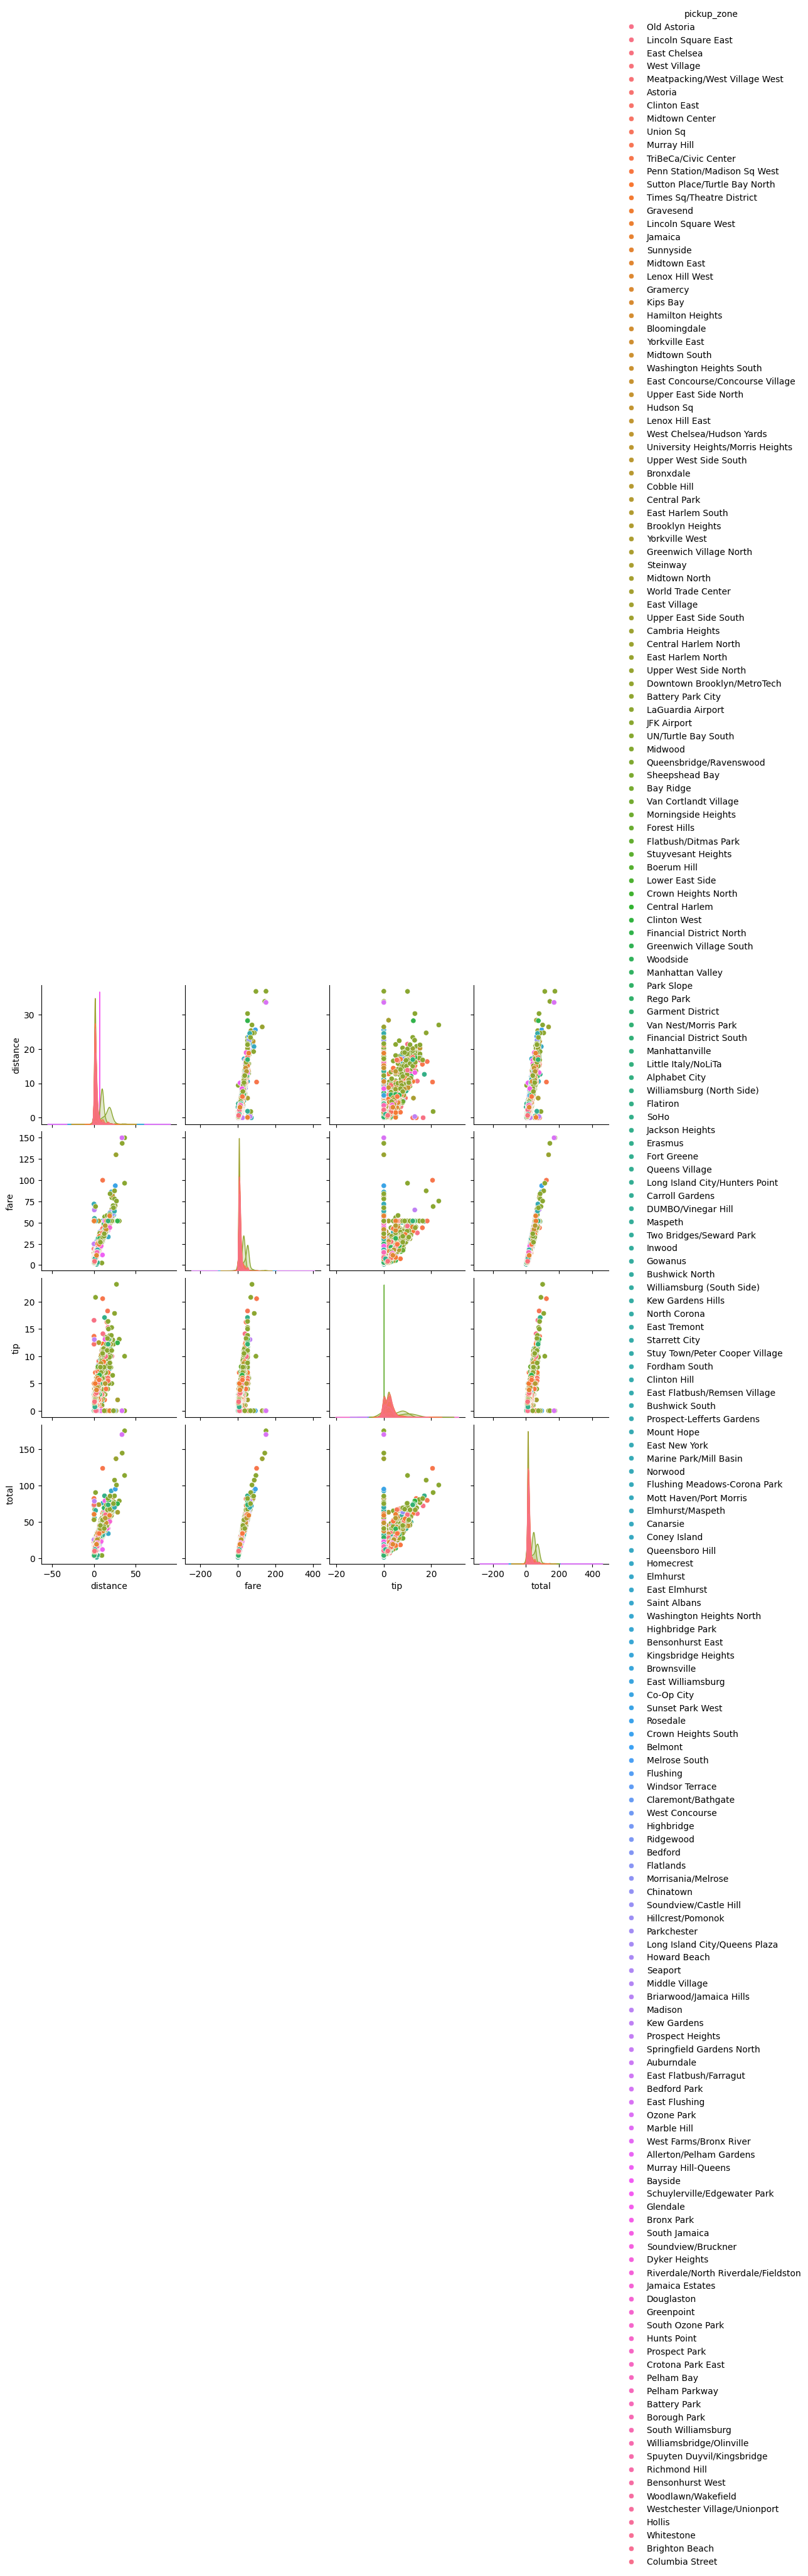

In [13]:
#Pair plot
pair_data = df[[
    "distance",
    "fare",
    "tip",
    "total",
    "pickup_zone"
]].dropna()

sns.pairplot(
    pair_data,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()


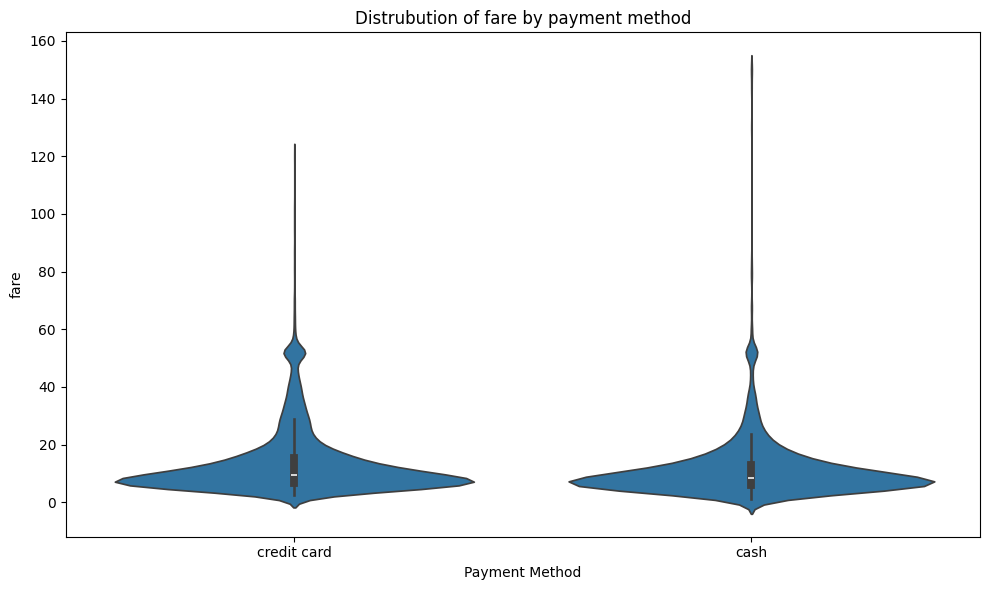

In [5]:
#violin plot
plt.figure(figsize=(10,6))

sns.violinplot(x="payment",y="fare",data=df)
plt.xlabel("Payment Method")
plt.ylabel("fare")
plt.title("Distrubution of fare by payment method")

plt.tight_layout()
plt.show()

